In [9]:
import pandas as pd

df = pd.read_csv("football_matches_2024_2025.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1941, 23)
['competition_code', 'competition_name', 'season', 'match_id', 'matchday', 'stage', 'status', 'date_utc', 'referee', 'home_team_id', 'home_team', 'away_team_id', 'away_team', 'fulltime_home', 'fulltime_away', 'halftime_home', 'halftime_away', 'goal_difference', 'total_goals', 'match_outcome', 'home_points', 'away_points', 'referee_id']
  competition_code competition_name     season  match_id  matchday  \
0               PL   Premier League  2024/2025    497410         1   
1               PL   Premier League  2024/2025    497411         1   
2               PL   Premier League  2024/2025    497412         1   
3               PL   Premier League  2024/2025    497413         1   
4               PL   Premier League  2024/2025    497414         1   

            stage    status                   date_utc         referee  \
0  REGULAR_SEASON  FINISHED  2024-08-16 19:00:00+00:00    Robert Jones   
1  REGULAR_SEASON  FINISHED  2024-08-17 11:30:00+00:00    Tim Robinson   
2  REGUL

In [10]:
print(df['match_outcome'].value_counts())
print(df['match_outcome'].value_counts(normalize=True) * 100)

match_outcome
Home Win    832
Away Win    646
Draw        463
Name: count, dtype: int64
match_outcome
Home Win    42.864503
Away Win    33.281813
Draw        23.853684
Name: proportion, dtype: float64


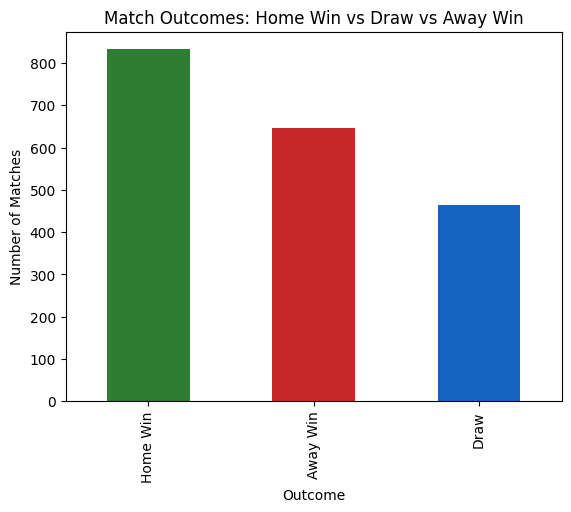

In [11]:
import matplotlib.pyplot as plt

df['match_outcome'].value_counts().plot(kind='bar', color=['#2E7D32','#C62828','#1565C0'])
plt.title('Match Outcomes: Home Win vs Draw vs Away Win')
plt.xlabel('Outcome')
plt.ylabel('Number of Matches')
plt.show()

In [12]:
outcome_by_comp = df.groupby('competition_name')['match_outcome'].value_counts(normalize=True).unstack() * 100
print(outcome_by_comp)

match_outcome           Away Win       Draw   Home Win
competition_name                                      
Bundesliga             36.274510  25.163399  38.562092
La Liga                30.000000  25.526316  44.473684
Ligue 1                33.006536  20.261438  46.732026
Premier League         34.736842  24.473684  40.789474
Serie A                31.842105  28.421053  39.736842
UEFA Champions League  35.449735  13.756614  50.793651


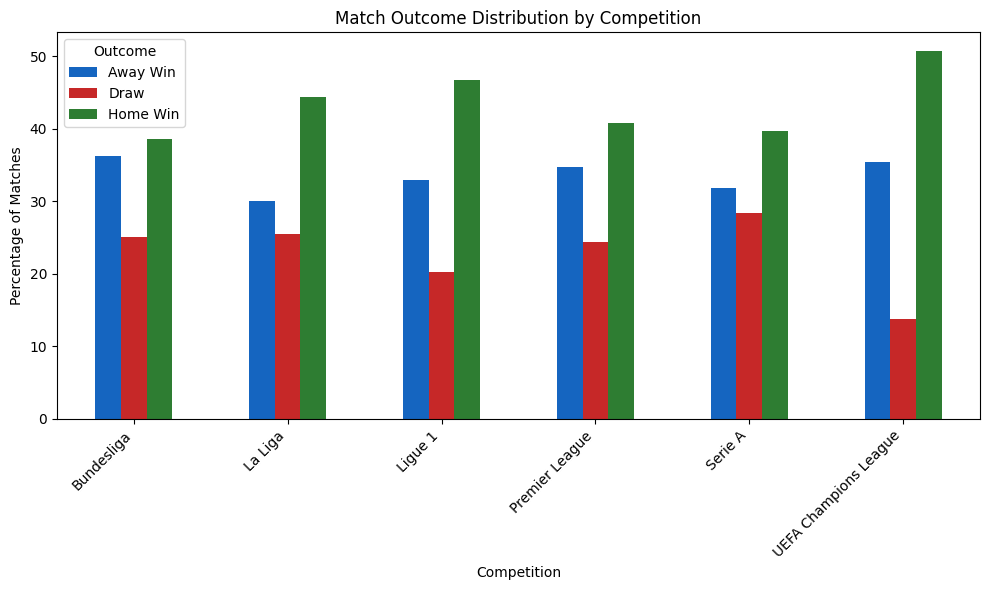

In [13]:
outcome_by_comp.plot(kind='bar', figsize=(10,6), color=['#1565C0','#C62828','#2E7D32'])
plt.title('Match Outcome Distribution by Competition')
plt.ylabel('Percentage of Matches')
plt.xlabel('Competition')
plt.legend(title='Outcome')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
df['date_utc'] = pd.to_datetime(df['date_utc'])
df = df.sort_values('date_utc').reset_index(drop=True)

In [15]:
home_rows = df[['date_utc','match_id','home_team','fulltime_home','fulltime_away','home_points']].copy()
home_rows.columns = ['date_utc','match_id','team','goals_for','goals_against','points']
home_rows['is_home'] = 1

away_rows = df[['date_utc','match_id','away_team','fulltime_away','fulltime_home','away_points']].copy()
away_rows.columns = ['date_utc','match_id','team','goals_for','goals_against','points']
away_rows['is_home'] = 0

team_matches = pd.concat([home_rows, away_rows]).sort_values(['team','date_utc']).reset_index(drop=True)
print(team_matches.head(10))

                   date_utc  match_id                   team  goals_for  \
0 2024-08-25 15:30:00+00:00    502379  1. FC Heidenheim 1846          2   
1 2024-09-01 13:30:00+00:00    502384  1. FC Heidenheim 1846          4   
2 2024-09-13 18:30:00+00:00    502390  1. FC Heidenheim 1846          2   
3 2024-09-21 13:30:00+00:00    502401  1. FC Heidenheim 1846          0   
4 2024-09-28 13:30:00+00:00    502413  1. FC Heidenheim 1846          2   
5 2024-10-06 13:30:00+00:00    502419  1. FC Heidenheim 1846          0   
6 2024-10-19 13:30:00+00:00    502432  1. FC Heidenheim 1846          2   
7 2024-10-27 18:30:00+00:00    502436  1. FC Heidenheim 1846          0   
8 2024-11-02 14:30:00+00:00    502451  1. FC Heidenheim 1846          0   
9 2024-11-10 18:30:00+00:00    502454  1. FC Heidenheim 1846          1   

   goals_against  points  is_home  
0              0       3        0  
1              0       3        1  
2              4       0        0  
3              3       0      

In [16]:
team_matches = team_matches.sort_values(['team', 'date_utc']).reset_index(drop=True)

grouped = team_matches.groupby('team')

team_matches['form_points_last5'] = grouped['points'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)
team_matches['form_goals_for_last5'] = grouped['goals_for'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)
team_matches['form_goals_against_last5'] = grouped['goals_against'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

print(team_matches.head(10))

                   date_utc  match_id                   team  goals_for  \
0 2024-08-25 15:30:00+00:00    502379  1. FC Heidenheim 1846          2   
1 2024-09-01 13:30:00+00:00    502384  1. FC Heidenheim 1846          4   
2 2024-09-13 18:30:00+00:00    502390  1. FC Heidenheim 1846          2   
3 2024-09-21 13:30:00+00:00    502401  1. FC Heidenheim 1846          0   
4 2024-09-28 13:30:00+00:00    502413  1. FC Heidenheim 1846          2   
5 2024-10-06 13:30:00+00:00    502419  1. FC Heidenheim 1846          0   
6 2024-10-19 13:30:00+00:00    502432  1. FC Heidenheim 1846          2   
7 2024-10-27 18:30:00+00:00    502436  1. FC Heidenheim 1846          0   
8 2024-11-02 14:30:00+00:00    502451  1. FC Heidenheim 1846          0   
9 2024-11-10 18:30:00+00:00    502454  1. FC Heidenheim 1846          1   

   goals_against  points  is_home  form_points_last5  form_goals_for_last5  \
0              0       3        0                NaN                   NaN   
1              0  

In [18]:
form_cols = ['match_id', 'team', 'form_points_last5', 'form_goals_for_last5', 'form_goals_against_last5']

home_form = team_matches[team_matches['is_home'] == 1][form_cols].copy()
home_form.columns = ['match_id', 'home_team', 'home_form_points', 'home_form_goals_for', 'home_form_goals_against']

away_form = team_matches[team_matches['is_home'] == 0][form_cols].copy()
away_form.columns = ['match_id', 'away_team', 'away_form_points', 'away_form_goals_for', 'away_form_goals_against']

model_df = df.merge(home_form, on=['match_id', 'home_team'], how='left')
model_df = model_df.merge(away_form, on=['match_id', 'away_team'], how='left')

print(model_df.shape)
print(model_df[['home_team','away_team','home_form_points','away_form_points','match_outcome']].head(10))

(1941, 29)
              home_team                   away_team  home_form_points  \
0         Athletic Club                   Getafe CF               NaN   
1   Real Betis Balompié                   Girona FC               NaN   
2      RC Celta de Vigo            Deportivo Alavés               NaN   
3           Le Havre AC      Paris Saint-Germain FC               NaN   
4  Manchester United FC                   Fulham FC               NaN   
5         UD Las Palmas                  Sevilla FC               NaN   
6       Ipswich Town FC                Liverpool FC               NaN   
7  Nottingham Forest FC             AFC Bournemouth               NaN   
8   Newcastle United FC              Southampton FC               NaN   
9            Arsenal FC  Wolverhampton Wanderers FC               NaN   

   away_form_points match_outcome  
0               NaN          Draw  
1               NaN          Draw  
2               NaN      Home Win  
3               NaN      Away Win  
4    

In [19]:
model_df_clean = model_df.dropna(subset=[
    'home_form_points', 'away_form_points',
    'home_form_goals_for', 'away_form_goals_for',
    'home_form_goals_against', 'away_form_goals_against'
]).reset_index(drop=True)

print(model_df_clean.shape)

(1882, 29)


In [20]:
features = [
    'home_form_points', 'home_form_goals_for', 'home_form_goals_against',
    'away_form_points', 'away_form_goals_for', 'away_form_goals_against'
]

X = model_df_clean[features]
y = model_df_clean['match_outcome']

print(X.shape, y.shape)
print(y.value_counts())

(1882, 6) (1882,)
match_outcome
Home Win    810
Away Win    628
Draw        444
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1505, 6) (377, 6)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5039787798408488

              precision    recall  f1-score   support

    Away Win       0.49      0.57      0.53       126
        Draw       0.00      0.00      0.00        89
    Home Win       0.51      0.73      0.60       162

    accuracy                           0.50       377
   macro avg       0.33      0.43      0.38       377
weighted avg       0.38      0.50      0.43       377


[[ 72   0  54]
 [ 31   0  58]
 [ 44   0 118]]


C:\Users\aashi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aashi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aashi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [23]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print()
print(classification_report(y_test, y_pred_balanced))
print()
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.46153846153846156

              precision    recall  f1-score   support

    Away Win       0.48      0.63      0.54       126
        Draw       0.22      0.20      0.21        89
    Home Win       0.60      0.47      0.53       162

    accuracy                           0.46       377
   macro avg       0.43      0.44      0.43       377
weighted avg       0.47      0.46      0.46       377


[[80 26 20]
 [41 18 30]
 [47 39 76]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))
print()
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.4297082228116711

              precision    recall  f1-score   support

    Away Win       0.41      0.46      0.43       126
        Draw       0.26      0.13      0.18        89
    Home Win       0.49      0.57      0.53       162

    accuracy                           0.43       377
   macro avg       0.38      0.39      0.38       377
weighted avg       0.41      0.43      0.41       377


[[58 18 50]
 [31 12 46]
 [53 17 92]]


away_form_goals_against    0.177454
home_form_goals_for        0.171942
home_form_goals_against    0.170073
away_form_goals_for        0.163370
home_form_points           0.158885
away_form_points           0.158277
dtype: float64


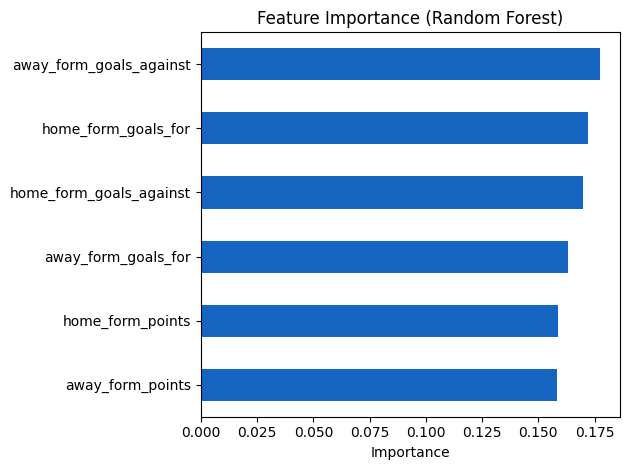

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', color='#1565C0')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
##SQL analysis
import sqlite3
import pandas as pd

df = pd.read_csv("football_matches_2024_2025.csv")

conn = sqlite3.connect("football.db")
df.to_sql("matches", conn, if_exists="replace", index=False)

# your first SQL query
result = pd.read_sql("SELECT * FROM matches LIMIT 5;", conn)
print(result)

  competition_code competition_name     season  match_id  matchday  \
0               PL   Premier League  2024/2025    497410         1   
1               PL   Premier League  2024/2025    497411         1   
2               PL   Premier League  2024/2025    497412         1   
3               PL   Premier League  2024/2025    497413         1   
4               PL   Premier League  2024/2025    497414         1   

            stage    status                   date_utc         referee  \
0  REGULAR_SEASON  FINISHED  2024-08-16 19:00:00+00:00    Robert Jones   
1  REGULAR_SEASON  FINISHED  2024-08-17 11:30:00+00:00    Tim Robinson   
2  REGULAR_SEASON  FINISHED  2024-08-17 14:00:00+00:00  Jarred Gillett   
3  REGULAR_SEASON  FINISHED  2024-08-17 14:00:00+00:00    Simon Hooper   
4  REGULAR_SEASON  FINISHED  2024-08-17 14:00:00+00:00    Craig Pawson   

   home_team_id  ... fulltime_home  fulltime_away halftime_home  \
0            66  ...             1              0             0   


In [27]:
query = """
SELECT home_team, away_team, match_outcome, total_goals
FROM matches
WHERE competition_name = 'Premier League'
LIMIT 10;
"""
result = pd.read_sql(query,conn)
print(result)


              home_team                   away_team match_outcome  total_goals
0  Manchester United FC                   Fulham FC      Home Win            1
1       Ipswich Town FC                Liverpool FC      Away Win            2
2            Arsenal FC  Wolverhampton Wanderers FC      Home Win            2
3            Everton FC   Brighton & Hove Albion FC      Away Win            3
4   Newcastle United FC              Southampton FC      Home Win            1
5  Nottingham Forest FC             AFC Bournemouth          Draw            2
6    West Ham United FC              Aston Villa FC      Away Win            3
7          Brentford FC           Crystal Palace FC      Home Win            3
8            Chelsea FC          Manchester City FC      Away Win            2
9     Leicester City FC        Tottenham Hotspur FC          Draw            2


In [30]:
query ="""
SELECT home_team, away_team, total_goals
FROM matches
WHERE total_goals > 5
"""
result = pd.read_sql(query,conn)
print(result)

                      home_team                   away_team  total_goals
0    Wolverhampton Wanderers FC                  Chelsea FC            8
1                    Arsenal FC           Leicester City FC            6
2                    Chelsea FC   Brighton & Hove Albion FC            6
3                  Brentford FC  Wolverhampton Wanderers FC            8
4                  Brentford FC             Ipswich Town FC            7
..                          ...                         ...          ...
138      Sport Lisboa e Benfica                FC Barcelona            9
139      Paris Saint-Germain FC          Manchester City FC            6
140              Real Madrid CF        FC Red Bull Salzburg            6
141                   Lille OSC         Feyenoord Rotterdam            7
142              Aston Villa FC                   Celtic FC            6

[143 rows x 3 columns]


In [29]:
query = """ 
SELECT *
FROM matches
WHERE match_outcome = 'Draw'
Limit 10;
"""
result = pd.read_sql(query,conn)
print(result)

  competition_code competition_name     season  match_id  matchday  \
0               PL   Premier League  2024/2025    497415         1   
1               PL   Premier League  2024/2025    497419         1   
2               PL   Premier League  2024/2025    497420         2   
3               PL   Premier League  2024/2025    497430         3   
4               PL   Premier League  2024/2025    497434         3   
5               PL   Premier League  2024/2025    497438         3   
6               PL   Premier League  2024/2025    497432         3   
7               PL   Premier League  2024/2025    497442         4   
8               PL   Premier League  2024/2025    497443         4   
9               PL   Premier League  2024/2025    497444         4   

            stage    status                   date_utc          referee  \
0  REGULAR_SEASON  FINISHED  2024-08-17 14:00:00+00:00   Michael Oliver   
1  REGULAR_SEASON  FINISHED  2024-08-19 19:00:00+00:00   Chris Kavanagh   
2  R

In [31]:
query = """ 
SELECT home_team, away_team, date_utc
FROM matches
ORDER BY date_utc DESC
LIMIT 10;
"""
result = pd.read_sql(query,conn)
print(result)

                home_team                 away_team                   date_utc
0  Paris Saint-Germain FC  FC Internazionale Milano  2025-05-31 19:00:00+00:00
1           Athletic Club              FC Barcelona  2025-05-25 19:00:00+00:00
2             Atalanta BC         Parma Calcio 1913  2025-05-25 18:45:00+00:00
3               Empoli FC          Hellas Verona FC  2025-05-25 18:45:00+00:00
4                SS Lazio                  US Lecce  2025-05-25 18:45:00+00:00
5               Torino FC                   AS Roma  2025-05-25 18:45:00+00:00
6          Udinese Calcio            ACF Fiorentina  2025-05-25 18:45:00+00:00
7              Venezia FC               Juventus FC  2025-05-25 18:45:00+00:00
8         AFC Bournemouth         Leicester City FC  2025-05-25 15:00:00+00:00
9               Fulham FC        Manchester City FC  2025-05-25 15:00:00+00:00


In [37]:
query = """
SELECT competition_name, AVG(total_goals) AS avg_goals
FROM matches
GROUP BY competition_name
ORDER BY avg_goals DESC;
"""
result = pd.read_sql(query, conn)
print(result)

        competition_name  avg_goals
0  UEFA Champions League   3.328042
1             Bundesliga   3.133987
2                Ligue 1   2.977124
3         Premier League   2.934211
4                La Liga   2.618421
5                Serie A   2.560526


In [39]:
query = """ 
SELECT competition_name, COUNT(*) AS match_count, SUM(total_goals) AS total_goals_scored
FROM matches
GROUP BY competition_name;
"""
result = pd.read_sql(query, conn)
print(result)

        competition_name  match_count  total_goals_scored
0             Bundesliga          306                 959
1                La Liga          380                 995
2                Ligue 1          306                 911
3         Premier League          380                1115
4                Serie A          380                 973
5  UEFA Champions League          189                 629


In [40]:
query = """
SELECT h.team, 
       h.home_games, h.home_points_total, h.avg_home_goals,
       a.away_games, a.away_points_total, a.avg_away_goals
FROM
    (SELECT home_team AS team, COUNT(*) AS home_games, SUM(home_points) AS home_points_total, AVG(fulltime_home) AS avg_home_goals
     FROM matches GROUP BY home_team) AS h
JOIN
    (SELECT away_team AS team, COUNT(*) AS away_games, SUM(away_points) AS away_points_total, AVG(fulltime_away) AS avg_away_goals
     FROM matches GROUP BY away_team) AS a
ON h.team = a.team
ORDER BY h.home_points_total DESC;
"""
result = pd.read_sql(query, conn)
print(result)

                         team  home_games  home_points_total  avg_home_goals  \
0              Real Madrid CF          26                 64        2.500000   
1      Paris Saint-Germain FC          26                 63        2.653846   
2    FC Internazionale Milano          26                 62        2.192308   
3                FC Barcelona          26                 60        2.923077   
4           FC Bayern München          24                 60        3.000000   
..                        ...         ...                ...             ...   
105           AC Sparta Praha           4                  3        1.000000   
106          FK Crvena Zvezda           4                  3        2.500000   
107            BSC Young Boys           4                  0        0.250000   
108      FC Red Bull Salzburg           4                  0        0.250000   
109      ŠK Slovan Bratislava           4                  0        1.000000   

     away_games  away_points_total  avg

In [41]:
result['points_gap'] = result['home_points_total'] - result['away_points_total']
top_gap = result.sort_values('points_gap', ascending=False).head(10)
print(top_gap[['team', 'home_points_total', 'away_points_total', 'points_gap']])

                         team  home_points_total  away_points_total  \
12               AS Monaco FC                 48                 27   
6              Aston Villa FC                 56                 35   
26                 CA Osasuna                 36                 16   
10         Manchester City FC                 50                 32   
39  RCD Espanyol de Barcelona                 30                 12   
9           Borussia Dortmund                 50                 33   
21          Stade Brestois 29                 40                 23   
27           RC Celta de Vigo                 36                 19   
0              Real Madrid CF                 64                 47   
13                  Lille OSC                 47                 30   

    points_gap  
12          21  
6           21  
26          20  
10          18  
39          18  
9           17  
21          17  
27          17  
0           17  
13          17  


# Conclusions

# Objective
This project explored football match outcomes across 6 major European competitions 
(2024/25 season) to answer: (1) does home advantage still matter, and (2) can recent 
team form predict match outcomes?

# Key Findings — EDA
- **Home advantage is real and significant**: Home teams won 42.9% of matches, 
  compared to 33.3% for away teams and 23.9% draws.
- **Home advantage varies by competition**: It was strongest in the UEFA Champions 
  League (~51% home win rate, only ~14% draws) and weakest in the Bundesliga 
  (~39% home win rate, with away win rate almost matching it at ~36%).

# Feature Engineering
Built rolling 5-match form features (points, goals for, goals against) for both 
home and away teams, calculated strictly from *prior* matches only (using shift 
+ rolling) to avoid data leakage. Matchday-1 games were dropped since no team had 
prior form data yet (1941 → 1882 rows).

# Modeling
Compared two classifiers predicting match outcome (Home Win / Draw / Away Win) 
from team form features:

| Model                                | Accuracy | Macro F1 | Notes                               |
|--------------------------------------|----------|----------|-------------------------------------|
| Logistic Regression (default)        | 50.4%    | 0.38     | Never predicted "Draw" at all       |
| Logistic Regression (class-balanced) | 46.2%    | 0.43     | Predicts all 3 classes, more useful |
| Random Forest (class-balanced)       | 43.0%    | 0.38     | Slightly worse than balanced LR     |

**Chose the class-balanced Logistic Regression** as the final model. Raw accuracy 
is not the best metric here — the default model's higher accuracy came from 
ignoring draws entirely, which is not a useful real-world prediction. The balanced 
model trades a few points of accuracy for actually attempting all three outcomes.

# Feature Importance
All six form features (goals for/against, points, home/away) contributed roughly 
equally (0.16–0.18 importance each) — no single stat dominates, suggesting match 
outcomes depend on a balanced mix of attacking and defensive form for both teams.

# SQL Analysis
To complement the Python-based analysis, the dataset was also loaded into a local 
SQLite database and re-analyzed using SQL (SELECT, WHERE, GROUP BY, aggregate 
functions, and a self-JOIN comparing home vs. away performance per team).

- **Scoring by competition**: Confirmed via SQL that the UEFA Champions League had 
  the highest average goals per match (3.33), followed by the Bundesliga (3.13); 
  Serie A was lowest (2.56).
- **Home vs. away performance gap**: A self-join comparing each team's home and 
  away points revealed that AS Monaco and Aston Villa had the largest home/away 
  gaps (21 points over the season), while top clubs like Real Madrid and Barcelona 
  performed far more consistently across venues — suggesting mid-table teams rely 
  more heavily on home advantage than elite teams do.

# Limitations
- Form-based features alone can't capture injuries, tactical changes, transfers, 
  or squad rotation.
- Single-season data (2024/25) — results may not generalize to other seasons.
- Draws remain genuinely hard to predict; even the balanced model only reached 
  ~20% recall on draws, reflecting how unpredictable close matches are.

# Possible Next Steps
- Add head-to-head history between specific teams
- Incorporate Elo-style team strength ratings
- Try gradient boosting (XGBoost/LightGBM) for comparison
- Use a time-based train/test split instead of random, for a more realistic evaluation